# Hematology Domain-Expert LLM — Training + Evaluation (Colab T4)

Companion notebook for the BSc thesis *"Development of a domain expert using a large language model like ChatGPT"*.

**Question this notebook answers:** does QLoRA fine-tuning on textbook-grounded Q&A make Llama-3.1-8B-Instruct a better hematology expert than the same model without fine-tuning?

**What it does**
1. Splits `train.jsonl` into **train (90 %) / held-out test (10 %)** — grouped so both Q&A pairs from the same textbook chunk stay on the same side (no leakage).
2. Fine-tunes Llama-3.1-8B-Instruct with QLoRA on the 90 % only.
3. Evaluates **base model vs. fine-tuned model** (same weights, adapter switched off/on) on:
   - **A. In-domain held-out Q&A** — ROUGE-L, semantic similarity to the gold answer, source-citation rate.
   - **B. External hematology MCQs** (MedMCQA, blood/haematology subset) — objective accuracy on questions the model never saw.
   - **C. Optional GPT-4o-mini judge** (needs an OpenAI key) — faithfulness & clinical correctness 1–5, plus GPT-4o as a reference system.
   - **D. Qualitative side-by-side** answers on clinical scenarios.
4. Saves tables, a chart and all raw answers to Google Drive for the thesis.

**Runtime:** `Runtime → Change runtime type → T4 GPU`. Total ≈ 1.5–2 h (training ≈ 40–60 min, evaluation ≈ 20–30 min, setup ≈ 10 min).

## 0. Settings

In [2]:
TRAIN_NEW      = True    # True = retrain on the 90% split (recommended: the old adapter saw ALL 2,098 pairs, so it would leak into the test set)
HF_ADAPTER     = 'Afridi07/hematology-llama-3.1-8b-lora'   # only used when TRAIN_NEW = False
BASE_MODEL     = 'unsloth/Meta-Llama-3.1-8B-Instruct-bnb-4bit'
EPOCHS         = 2
N_INDOMAIN     = 100     # held-out Q&A to score (max ~210)
N_MCQ          = 200     # MedMCQA hematology questions
USE_JUDGE      = True    # needs Colab secret OPENAI_API_KEY; skipped automatically if missing
JUDGE_MODEL    = 'gpt-4o-mini'
GPT4O_BASELINE = True    # also answer the in-domain questions with GPT-4o as a reference (costs < $1)
SEED           = 42
OUT_DIR        = '/content/drive/MyDrive/thesis_domain_expert'
SYSTEM_PROMPT  = ('You are a clinical hematology expert. Always ground answers in the provided textbook reference. '
                  'Use cautious, evidence-based language. When evidence is insufficient, say so explicitly. '
                  'Cite using [Reference N] when paraphrasing the source.')

## 1. Environment

In [ ]:
from google.colab import userdata
userdata.get('OPENAI_API_KEY')

In [5]:
!nvidia-smi --query-gpu=name,memory.total --format=csv
%pip install -q unsloth
%pip install -q rouge_score sentence-transformers openai

name, memory.total [MiB]
Tesla T4, 15360 MiB
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.1/81.1 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.4/25.4 MB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 40.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 101.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 37.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 81.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 98.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 98.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.9/216.9 kB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.7/119.7 kB 12.7 MB/s eta 0:00:00
   ━

In [6]:
import os, json, random, re, time, statistics
from google.colab import drive
drive.mount('/content/drive')
os.makedirs(OUT_DIR, exist_ok=True)
random.seed(SEED)
print('Outputs ->', OUT_DIR)

Mounted at /content/drive
Outputs -> /content/drive/MyDrive/thesis_domain_expert


## 2. Data: grouped 90 / 10 split
Upload `data/finetune/train.jsonl` from the repo when prompted. The generator wrote **2 pairs per textbook chunk, consecutively**, so record `i` belongs to chunk `i // 2`; the split is made over chunks.

In [7]:
from google.colab import files
up = files.upload()                       # choose train.jsonl
FNAME = next(iter(up))
records = [json.loads(l) for l in open(FNAME, encoding='utf-8') if l.strip()]
print('records:', len(records))

groups = sorted({i // 2 for i in range(len(records))})
rng = random.Random(SEED); rng.shuffle(groups)
test_groups = set(groups[: int(0.10 * len(groups))])
train_recs = [r for i, r in enumerate(records) if i // 2 not in test_groups]
test_recs  = [r for i, r in enumerate(records) if i // 2 in test_groups]
print(f'train: {len(train_recs)}   held-out test: {len(test_recs)}')

for name, rs in [('train_split.jsonl', train_recs), ('test_split.jsonl', test_recs)]:
    with open(f'{OUT_DIR}/{name}', 'w', encoding='utf-8') as f:
        for r in rs: f.write(json.dumps(r, ensure_ascii=False) + '\n')

Saving train.jsonl to train.jsonl
records: 2098
train: 1890   held-out test: 208


## 3. Model: train a new adapter (or load the existing one)

In [8]:
from unsloth import FastLanguageModel
import torch
MAX_SEQ = 2048

if TRAIN_NEW:
    model, tokenizer = FastLanguageModel.from_pretrained(BASE_MODEL, max_seq_length=MAX_SEQ, load_in_4bit=True)
    model = FastLanguageModel.get_peft_model(
        model, r=16, lora_alpha=32, lora_dropout=0.0,
        target_modules=['q_proj','k_proj','v_proj','o_proj','gate_proj','up_proj','down_proj'],
        use_gradient_checkpointing='unsloth', random_state=SEED, bias='none')
else:
    from google.colab import userdata
    try: tok = userdata.get('HF_TOKEN')
    except Exception: tok = None
    model, tokenizer = FastLanguageModel.from_pretrained(HF_ADAPTER, max_seq_length=MAX_SEQ, load_in_4bit=True, token=tok)
print(type(model).__name__)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.9.12: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Unsloth: Will load unsloth/Meta-Llama-3.1-8B-Instruct-bnb-4bit as a legacy tokenizer.
Unsloth 2026.9.12 patched 32 layers with 32 QKV layers, 32 O layers and 32 MLP layers.


PeftModelForCausalLM


Map:   0%|          | 0/1890 [00:00<?, ? examples/s]

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 1,890 | Num Epochs = 2 | Total steps = 474
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 41,943,040 of 8,072,204,288 (0.52% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Unsloth: Will smartly offload gradients to save VRAM!


/usr/local/lib/python3.13/dist-packages/unsloth/import_fixes.py:5317: UserWarning: 'has_cuda' is deprecated, please use 'torch.backends.cuda.is_built()'
  return original(name)
/usr/local/lib/python3.13/dist-packages/unsloth/import_fixes.py:5317: UserWarning: 'has_cudnn' is deprecated, please use 'torch.backends.cudnn.is_available()'
  return original(name)
/usr/local/lib/python3.13/dist-packages/unsloth/import_fixes.py:5317: UserWarning: 'has_mps' is deprecated, please use 'torch.backends.mps.is_built()'
  return original(name)
/usr/local/lib/python3.13/dist-packages/unsloth/import_fixes.py:5317: UserWarning: 'has_mkldnn' is deprecated, please use 'torch.backends.mkldnn.is_available()'
  return original(name)


Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.


Step,Training Loss
10,2.666650
20,0.788458
30,0.661536
40,0.614682
50,0.572658
60,0.602146
70,0.549946
80,0.558054
90,0.570135
100,0.555119


Training done in 49.8 min


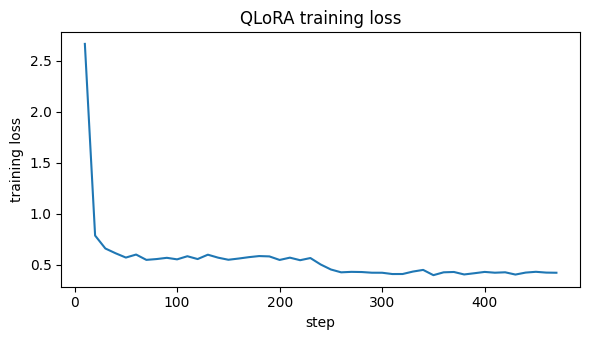

Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/thesis_domain_expert/hema-llama-lora/tokenizer_config.json.


Adapter saved to Drive.


In [9]:
if TRAIN_NEW:
    from datasets import Dataset
    from trl import SFTTrainer, SFTConfig
    from transformers import DataCollatorForLanguageModeling

    def render(ex):
        text = tokenizer.apply_chat_template(ex['messages'], tokenize=False)
        enc = tokenizer(text, truncation=True, max_length=MAX_SEQ)
        return {'input_ids': enc['input_ids'], 'attention_mask': enc['attention_mask']}
    train_ds = Dataset.from_list(train_recs).map(render, remove_columns=['messages']).shuffle(seed=SEED)

    cfg = SFTConfig(
        output_dir='outputs', per_device_train_batch_size=2, gradient_accumulation_steps=4,
        warmup_steps=10, num_train_epochs=EPOCHS, learning_rate=2e-4, weight_decay=0.01,
        lr_scheduler_type='linear', optim='adamw_8bit', logging_steps=10, seed=SEED,
        fp16=not torch.cuda.is_bf16_supported(), bf16=torch.cuda.is_bf16_supported(),
        save_strategy='no', report_to='none', max_seq_length=MAX_SEQ,
        dataset_kwargs={'skip_prepare_dataset': True}, remove_unused_columns=False)
    trainer = SFTTrainer(model=model, processing_class=tokenizer, train_dataset=train_ds,
                         data_collator=DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False), args=cfg)
    t0 = time.time(); stats = trainer.train(); train_minutes = (time.time() - t0) / 60
    print(f'Training done in {train_minutes:.1f} min')

    # save loss curve + adapter to Drive
    log = [h for h in trainer.state.log_history if 'loss' in h]
    json.dump(log, open(f'{OUT_DIR}/train_log.json', 'w'), indent=1)
    import matplotlib.pyplot as plt
    plt.figure(figsize=(6,3.5)); plt.plot([h['step'] for h in log], [h['loss'] for h in log])
    plt.xlabel('step'); plt.ylabel('training loss'); plt.title('QLoRA training loss'); plt.tight_layout()
    plt.savefig(f'{OUT_DIR}/training_loss.png', dpi=200); plt.show()
    model.save_pretrained(f'{OUT_DIR}/hema-llama-lora'); tokenizer.save_pretrained(f'{OUT_DIR}/hema-llama-lora')
    print('Adapter saved to Drive.')

## 4. Generation helpers
The **same model object** is used for both systems: `model.disable_adapter()` gives the original Llama-3.1-8B-Instruct, otherwise the fine-tuned adapter is active. Greedy decoding for reproducibility.

In [10]:
FastLanguageModel.for_inference(model)
tokenizer.padding_side = 'left'
if tokenizer.pad_token is None: tokenizer.pad_token = tokenizer.eos_token

@torch.no_grad()
def generate(prompts, system=SYSTEM_PROMPT, max_new_tokens=256, batch_size=8, adapter=True):
    outs = []
    for i in range(0, len(prompts), batch_size):
        chunk = prompts[i:i+batch_size]
        texts = [tokenizer.apply_chat_template([{'role':'system','content':system},{'role':'user','content':p}],
                                               tokenize=False, add_generation_prompt=True) for p in chunk]
        enc = tokenizer(texts, return_tensors='pt', padding=True, add_special_tokens=False).to('cuda')
        def _gen():
            return model.generate(**enc, max_new_tokens=max_new_tokens, do_sample=False,
                                  pad_token_id=tokenizer.pad_token_id)
        if adapter: out = _gen()
        else:
            with model.disable_adapter(): out = _gen()
        outs += [tokenizer.decode(o[enc['input_ids'].shape[1]:], skip_special_tokens=True).strip() for o in out]
        print(f'  {min(i+batch_size, len(prompts))}/{len(prompts)}', end='\r')
    return outs

print(generate(['What is the normal lifespan of a red blood cell?'], max_new_tokens=60)[0])

Both `max_new_tokens` (=60) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


The normal lifespan of a red blood cell is 120 days.

Source: essentials_haematology.pdf.


## 5A. In-domain held-out Q&A (base vs. fine-tuned)

In [11]:
def qa(rec):
    m = rec['messages']
    return next(x['content'] for x in m if x['role']=='user'), next(x['content'] for x in m if x['role']=='assistant')
eval_items = [qa(r) for r in test_recs[:N_INDOMAIN]]
questions = [q for q, _ in eval_items]; golds = [g for _, g in eval_items]

t0 = time.time(); ans_base = generate(questions, adapter=False); tb = time.time() - t0
t0 = time.time(); ans_ft   = generate(questions, adapter=True);  tf = time.time() - t0
print(f'\nbase: {tb/len(questions):.1f}s/answer   fine-tuned: {tf/len(questions):.1f}s/answer')

systems = {'Llama-3.1-8B (base)': ans_base, 'Llama-3.1-8B + QLoRA (ours)': ans_ft}

if GPT4O_BASELINE:
    try:
        from google.colab import userdata
        from openai import OpenAI
        oa = OpenAI(api_key=userdata.get('OPENAI_API_KEY'))
        ans_gpt = []
        for q in questions:
            r = oa.chat.completions.create(model='gpt-4o', temperature=0, max_tokens=300,
                    messages=[{'role':'system','content':SYSTEM_PROMPT},{'role':'user','content':q}])
            ans_gpt.append(r.choices[0].message.content.strip())
        systems['GPT-4o (reference)'] = ans_gpt
    except Exception as e:
        print('GPT-4o baseline skipped:', e)

Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  100/100
base: 7.7s/answer   fine-tuned: 3.7s/answer


In [12]:
from rouge_score import rouge_scorer
from sentence_transformers import SentenceTransformer, util
rs = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
emb = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2', device='cuda')
gold_emb = emb.encode(golds, convert_to_tensor=True, normalize_embeddings=True)
cite_re = re.compile(r'source:|\[reference|haematology\.pdf', re.I)

def text_metrics(preds):
    rl = [rs.score(g, p)['rougeL'].fmeasure for g, p in zip(golds, preds)]
    pe = emb.encode(preds, convert_to_tensor=True, normalize_embeddings=True)
    sim = util.cos_sim(pe, gold_emb).diagonal().cpu().tolist()
    return {'ROUGE-L': statistics.mean(rl), 'Semantic sim.': statistics.mean(sim),
            'Cites source (%)': 100 * sum(bool(cite_re.search(p)) for p in preds) / len(preds),
            'Avg. words': statistics.mean(len(p.split()) for p in preds)}

import pandas as pd
res_A = pd.DataFrame({k: text_metrics(v) for k, v in systems.items()}).T.round(3)
res_A

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

,ROUGE-L,Semantic sim.,Cites source (%),Avg. words
Llama-3.1-8B (base),0.161,0.752,7.0,158.49
Llama-3.1-8B + QLoRA (ours),0.433,0.831,100.0,39.36
GPT-4o (reference),0.181,0.774,88.0,159.94


## 5B. External hematology MCQs (MedMCQA)
Questions from Indian medical entrance exams — **not** generated from the thesis textbooks, so this tests whether general hematology knowledge was kept or improved (and checks that fine-tuning did not cause forgetting).

In [13]:
from datasets import load_dataset
mm = load_dataset('openlifescienceai/medmcqa', split='validation')
hema_re = re.compile(r'haemat|hemat|anaemi|anemi|leuk|lymphom|myelo|platelet|thrombo|coagul|haemoglob|hemoglob|'
                     r'neutrophil|eosinophil|basophil|erythro|blood cell|haemophil|hemophil|sickle|thalass', re.I)
pool = [x for x in mm if x['choice_type'] == 'single' and
        (hema_re.search(x['topic_name'] or '') or hema_re.search(x['question']))]
random.Random(SEED).shuffle(pool); mcq = pool[:N_MCQ]
print('hematology MCQs available:', len(pool), ' used:', len(mcq))

L = 'ABCD'
def mcq_prompt(x):
    return (f"{x['question']}\n\nOptions:\nA. {x['opa']}\nB. {x['opb']}\nC. {x['opc']}\nD. {x['opd']}\n\n"
            'Answer with the single letter of the correct option only.')
def letter(t):
    m = re.search(r'\b([ABCD])\b', t.upper()); return m.group(1) if m else None

mp = [mcq_prompt(x) for x in mcq]; gold_l = [L[x['cop']] for x in mcq]
mcq_base = generate(mp, max_new_tokens=8, batch_size=16, adapter=False)
mcq_ft   = generate(mp, max_new_tokens=8, batch_size=16, adapter=True)
acc = lambda preds: 100 * sum(letter(p) == g for p, g in zip(preds, gold_l)) / len(gold_l)
res_B = pd.DataFrame({'MedMCQA hematology acc. (%)': {'Llama-3.1-8B (base)': acc(mcq_base),
                                                      'Llama-3.1-8B + QLoRA (ours)': acc(mcq_ft)}}).round(1)
print(f'(random guessing = 25 %,  n = {len(mcq)})'); res_B

README.md:   0%|          | 0.00/10.7k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 85.9MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  936kB            

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

Both `max_new_tokens` (=8) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Both `max_new_tokens` (=8) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Both `max_new_tokens` (=8) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


(random guessing = 25 %,  n = 100)


,MedMCQA hematology acc. (%)
Llama-3.1-8B (base),56.0
Llama-3.1-8B + QLoRA (ours),57.0


## 5C. LLM-as-judge (optional, GPT-4o-mini)
The judge sees the question, the textbook-grounded gold answer and the model answer, and scores 1–5. It does **not** know which system wrote the answer.

In [14]:
res_C = None
if USE_JUDGE:
    try:
        from google.colab import userdata
        from openai import OpenAI
        judge = OpenAI(api_key=userdata.get('OPENAI_API_KEY'))
        JP = ('You are grading a hematology assistant. Score 1-5 (5 = best). Return STRICT JSON '
              '{"faithfulness": int, "clinical_correctness": int}. Faithfulness = agrees with the GOLD textbook answer '
              'and adds no unsupported claims. Clinical correctness = medically accurate.\n\n'
              'QUESTION:\n{q}\n\nGOLD ANSWER:\n{g}\n\nMODEL ANSWER:\n{p}')
        def score(q, g, p):
            r = judge.chat.completions.create(model=JUDGE_MODEL, temperature=0, response_format={'type':'json_object'},
                    messages=[{'role':'user','content':JP.format(q=q, g=g, p=p)}])
            return json.loads(r.choices[0].message.content)
        judged = {}
        for name, preds in systems.items():
            s = [score(q, g, p) for q, g, p in zip(questions, golds, preds)]
            judged[name] = s
            print(name, 'done')
        res_C = pd.DataFrame({n: {'Faithfulness (1-5)': statistics.mean(x['faithfulness'] for x in s),
                                  'Clinical correctness (1-5)': statistics.mean(x['clinical_correctness'] for x in s)}
                              for n, s in judged.items()}).T.round(2)
        json.dump(judged, open(f'{OUT_DIR}/judge_scores.json', 'w'), indent=1)
    except Exception as e:
        print('Judge skipped:', e)
res_C

Judge skipped: '"faithfulness"'


## 5D. Qualitative side-by-side (for the thesis)

In [15]:
cases = [
    'A peripheral smear shows 78% neutrophils with toxic granulation and the CBC reports WBC 18.0 x10^9/L. Interpret.',
    'An automated analyser classified only 2 white cells on a smear: 1 immature granulocyte and 1 monocyte. What can be concluded about the differential?',
    'Hb 9.1 g/dL, MCV 68 fL, target cells on the film. What is the differential diagnosis and which test would you order next?',
    'What morphological features distinguish a myeloblast from a lymphoblast on a Romanowsky-stained smear?',
    'Is a platelet count of 90 x10^9/L on an automated analyser always true thrombocytopenia?',
]
q_base = generate(cases, max_new_tokens=350, adapter=False)
q_ft   = generate(cases, max_new_tokens=350, adapter=True)
qual = [{'question': c, 'base': b, 'fine_tuned': f} for c, b, f in zip(cases, q_base, q_ft)]
for x in qual:
    print('='*100, '\nQ:', x['question'], '\n\n--- BASE ---\n', x['base'], '\n\n--- FINE-TUNED ---\n', x['fine_tuned'])

Both `max_new_tokens` (=350) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=350) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Q: A peripheral smear shows 78% neutrophils with toxic granulation and the CBC reports WBC 18.0 x10^9/L. Interpret. 

--- BASE ---
 Based on the provided information, the peripheral smear shows 78% neutrophils with toxic granulation, and the CBC reports a WBC count of 18.0 x 10^9/L.

Toxic granulation in neutrophils is often associated with a condition known as leukemoid reaction or severe infection, particularly bacterial infections [1]. The presence of toxic granulation suggests that the neutrophils are activated and have undergone changes in response to an inflammatory stimulus.

The elevated WBC count of 18.0 x 10^9/L is also consistent with a leukemoid reaction or a severe infection. In a leukemoid reaction, the WBC count is elevated due to the release of immature neutrophils from the bone marrow in response to an inflammatory stimulus [2].

However, it is essential to note that an elevated WBC count can also be seen in other conditions, such as leukemia or lymphoma. Further diagn

## 6. Save everything for the thesis

|                             |   ROUGE-L |   Semantic sim. |   Cites source (%) |   Avg. words |   MedMCQA hematology acc. (%) |
|:----------------------------|----------:|----------------:|-------------------:|-------------:|------------------------------:|
| Llama-3.1-8B (base)         |     0.161 |           0.752 |                  7 |       158.49 |                            56 |
| Llama-3.1-8B + QLoRA (ours) |     0.433 |           0.831 |                100 |        39.36 |                            57 |
| GPT-4o (reference)          |     0.181 |           0.774 |                 88 |       159.94 |                           nan |


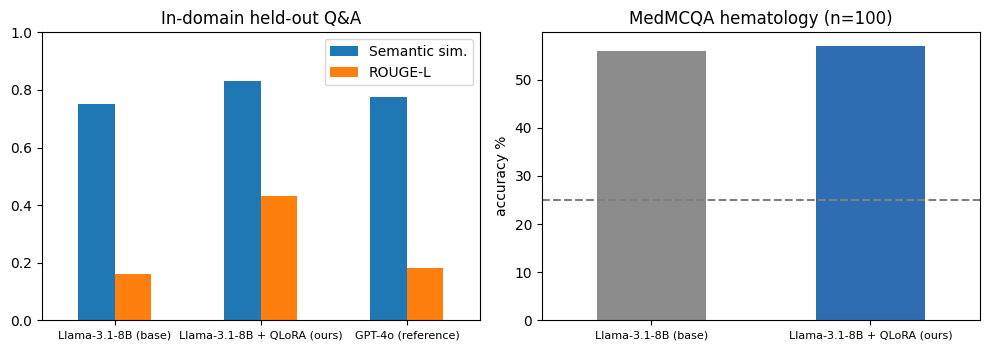


Saved to /content/drive/MyDrive/thesis_domain_expert : ['train_split.jsonl', 'test_split.jsonl', 'train_log.json', 'training_loss.png', 'hema-llama-lora', 'results_summary.csv', 'results_chart.png', 'evaluation_report.json']


In [16]:
import matplotlib.pyplot as plt
summary = res_A.join(res_B, how='left')
if res_C is not None: summary = summary.join(res_C, how='left')
summary.to_csv(f'{OUT_DIR}/results_summary.csv')
print(summary.to_markdown())

cols = [c for c in ['Semantic sim.', 'ROUGE-L'] if c in summary]
fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
summary[cols].plot.bar(ax=ax[0], rot=0); ax[0].set_title('In-domain held-out Q&A'); ax[0].set_ylim(0, 1)
summary['MedMCQA hematology acc. (%)'].dropna().plot.bar(ax=ax[1], rot=0, color=['#8c8c8c', '#2f6db3'])
ax[1].axhline(25, ls='--', c='grey'); ax[1].set_title(f'MedMCQA hematology (n={len(mcq)})'); ax[1].set_ylabel('accuracy %')
for a in ax: a.tick_params(axis='x', labelsize=8)
plt.tight_layout(); plt.savefig(f'{OUT_DIR}/results_chart.png', dpi=200); plt.show()

json.dump({'config': {'train_new': TRAIN_NEW, 'epochs': EPOCHS, 'base_model': BASE_MODEL, 'seed': SEED,
                      'n_train': len(train_recs), 'n_test_total': len(test_recs), 'n_indomain_scored': len(questions),
                      'n_mcq': len(mcq)},
           'summary': json.loads(summary.to_json(orient='index')),
           'indomain_answers': [{'q': q, 'gold': g, **{k: v[i] for k, v in systems.items()}} for i, (q, g) in enumerate(eval_items)],
           'mcq_answers': [{'q': p, 'gold': g, 'base': b, 'ft': f} for p, g, b, f in zip(mp, gold_l, mcq_base, mcq_ft)],
           'qualitative': qual},
          open(f'{OUT_DIR}/evaluation_report.json', 'w', encoding='utf-8'), indent=1, ensure_ascii=False)
print('\nSaved to', OUT_DIR, ':', os.listdir(OUT_DIR))

## 7. How to read the results (for the thesis)
* **In-domain Q&A** measures whether the model learned the *textbook's* knowledge and answering style. Gains here are expected; the gold answers were generated from the same textbooks, so treat this as in-distribution evidence.
* **MedMCQA** is the harder, external test. If fine-tuned ≈ base, fine-tuning taught style and grounding behaviour without harming general knowledge; if it drops, report it as *catastrophic forgetting* and discuss it — that is still a valid finding.
* **Judge scores** are automated, not clinician ratings — describe them as such.
* Report the *numbers you get*, including any that do not favour the fine-tuned model.